# Regime-Shift Asset Allocation
### Summer of Quant — Advanced Project

**What this notebook does, in one sentence:** it looks at daily market data, uses a Hidden
Markov Model to work out whether the market is currently in a **Bull**, **Bear**, or
**Crisis** regime, then leans on convex optimization (`cvxpy`) to pick portfolio weights
across **equity / gold / bonds** that make sense for that regime. And then it proves the
whole thing actually holds up out-of-sample, via walk-forward validation, with realistic
transaction costs baked in.

**Pipeline:** `data → features → regime detection (HMM) → walk-forward validation →
portfolio optimization → backtest → performance report`

**A note on data:** this notebook first tries to pull live data from Yahoo Finance
(`yfinance`) — Nifty 50, a gold ETF, a gilt-fund ETF, India VIX. If it can't reach Yahoo
Finance — no internet, a rate limit, a sandboxed environment, whatever the reason — it
falls back automatically to a **synthetic regime-switching market** it generates on its
own. Every cell below still runs top-to-bottom either way, and every chart and number is
real output. Just not from real markets, when the fallback kicks in. The active data
source gets printed clearly, no guessing required. **Run this with internet access to
Yahoo Finance if you want the real submission results.**


## 0. Setup


In [ ]:
# !pip install yfinance hmmlearn cvxpy scikit-learn matplotlib pandas numpy scipy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", None)
np.random.seed(7)

## Phase 1 — Get and Understand the Data

**Goal:** a clean, aligned daily price dataset for equity / gold / bonds, plus India VIX as
a volatility/fear proxy.

**Tickers used (Yahoo Finance):**
| Asset | Ticker | Why |
|---|---|---|
| Equity | `^NSEI` | Nifty 50 index — broad Indian equity market |
| Gold | `GOLDBEES.NS` | Nippon India ETF Gold BeES — liquid, INR-denominated gold proxy |
| Bonds | `LTGILTBEES.NS` | Nippon India ETF Long Term Gilt — Indian government bond proxy |
| Volatility | `^INDIAVIX` | India VIX — the market's own forward-looking fear gauge |

If live data isn't reachable, `load_prices()` falls back to a synthetic market. Not just
any synthetic market, either — one generated from a true (hidden) 3-state Markov regime
process. That's deliberate. It means the "ground truth" regime is known, so we can
sanity-check what the HMM actually recovers, honestly.


In [2]:
"""
Data acquisition for the Regime-Shift Asset Allocation project.

Tries to pull real data from Yahoo Finance via yfinance. If that fails
(e.g. no internet access, rate-limited, ticker changed), falls back to a
synthetic-but-realistic regime-switching price generator so the rest of
the pipeline can still be built, tested, and demonstrated end to end.

The synthetic path is ONLY a development/testing convenience. It is
loudly labeled everywhere it's used. Swap USE_LIVE_DATA / just run this
with internet access to get the real submission-quality results.
"""
import numpy as np
import pandas as pd

TICKERS = {
    "equity": "^NSEI",         # Nifty 50 index
    "gold":   "GOLDBEES.NS",   # Nippon India ETF Gold BeES (gold proxy, INR)
    "bond":   "LTGILTBEES.NS", # Nippon India ETF Long Term Gilt (bond proxy, INR)
    "vix":    "^INDIAVIX",     # India VIX
}

START = "2012-01-01"
END = "2026-07-01"


def _try_yfinance():
    import yfinance as yf
    frames = {}
    for name, ticker in TICKERS.items():
        df = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if df is None or df.empty:
            raise RuntimeError(f"No data returned for {ticker}")
        frames[name] = df["Close"]
    prices = pd.DataFrame(frames).dropna(how="all")
    if len(prices) < 500:
        raise RuntimeError("Suspiciously little data returned - treating as a failed pull")
    return prices


def _synthetic_regime_market(seed=7, n_days=3200):
    """
    Simulates NSE-like equity, a gold-like asset, a bond-like asset, and a
    VIX-like fear index, all driven by a true underlying 3-state Markov
    regime (Bull / Bear / Crisis) that the rest of the notebook is NOT
    allowed to see directly - only through the noisy price/vol data, same
    as in real life. This lets us test the HMM + optimizer + backtest
    honestly before pointing the pipeline at real Yahoo Finance data.
    """
    rng = np.random.default_rng(seed)

    # True hidden regime process (unknown to the model - ground truth for testing only)
    # 0 = Bull, 1 = Bear, 2 = Crisis
    P_true = np.array([
        [0.985, 0.012, 0.003],
        [0.02,  0.96,  0.02],
        [0.03,  0.05,  0.92],
    ])
    regime_params = {
        # (equity_drift, equity_vol, gold_drift, gold_vol, bond_drift, bond_vol, vix_level, vix_vol)
        0: dict(eq_mu=0.00080, eq_sig=0.0065, gold_mu=0.00015, gold_sig=0.006,
                bond_mu=0.00020, bond_sig=0.0020, vix_lvl=12, vix_sig=1.3),
        1: dict(eq_mu=-0.00040, eq_sig=0.0155, gold_mu=0.00030, gold_sig=0.008,
                bond_mu=0.00025, bond_sig=0.0028, vix_lvl=20, vix_sig=2.5),
        2: dict(eq_mu=-0.0028, eq_sig=0.038, gold_mu=0.00060, gold_sig=0.014,
                bond_mu=0.00010, bond_sig=0.0060, vix_lvl=42, vix_sig=8.0),
    }

    states = np.zeros(n_days, dtype=int)
    states[0] = 0
    for t in range(1, n_days):
        states[t] = rng.choice(3, p=P_true[states[t - 1]])

    eq_ret = np.zeros(n_days)
    gold_ret = np.zeros(n_days)
    bond_ret = np.zeros(n_days)
    vix = np.zeros(n_days)

    for t in range(n_days):
        p = regime_params[states[t]]
        eq_ret[t] = rng.normal(p["eq_mu"], p["eq_sig"])
        gold_ret[t] = rng.normal(p["gold_mu"], p["gold_sig"])
        bond_ret[t] = rng.normal(p["bond_mu"], p["bond_sig"])
        vix[t] = max(8.0, rng.normal(p["vix_lvl"], p["vix_sig"]))

    dates = pd.bdate_range(end=END, periods=n_days)
    equity = 8000 * np.exp(np.cumsum(eq_ret))
    gold = 40 * np.exp(np.cumsum(gold_ret))
    bond = 20 * np.exp(np.cumsum(bond_ret))

    prices = pd.DataFrame(
        {"equity": equity, "gold": gold, "bond": bond, "vix": vix},
        index=dates,
    )
    prices.attrs["true_states"] = pd.Series(states, index=dates, name="true_regime")
    return prices


def load_prices(verbose=True):
    """
    Returns a DataFrame with columns [equity, gold, bond, vix] indexed by date.
    Tries live Yahoo Finance data first; falls back to a synthetic
    regime-switching market if that isn't reachable, clearly flagging which
    path was used via `prices.attrs["source"]`.
    """
    try:
        prices = _try_yfinance()
        prices.attrs["source"] = "yfinance (live)"
        if verbose:
            print(f"Loaded LIVE data from Yahoo Finance: {len(prices)} rows, "
                  f"{prices.index.min().date()} to {prices.index.max().date()}")
        return prices
    except Exception as e:
        if verbose:
            print(f"[data] Live Yahoo Finance pull failed ({e!r}).")
            print("[data] Falling back to SYNTHETIC regime-switching data for "
                  "development/testing. Re-run with internet access to Yahoo "
                  "Finance for the real submission results.")
        prices = _synthetic_regime_market()
        prices.attrs["source"] = "synthetic (fallback)"
        if verbose:
            print(f"Generated SYNTHETIC data: {len(prices)} rows, "
                  f"{prices.index.min().date()} to {prices.index.max().date()}")
        return prices


if __name__ == "__main__":
    px = load_prices()
    print(px.attrs["source"])
    print(px.head())
    print(px.tail())

Failed to get ticker '^NSEI' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.



1 Failed download:


['^NSEI']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


[data] Live Yahoo Finance pull failed (RuntimeError('No data returned for ^NSEI')).
[data] Falling back to SYNTHETIC regime-switching data for development/testing. Re-run with internet access to Yahoo Finance for the real submission results.
Generated SYNTHETIC data: 3200 rows, 2014-03-27 to 2026-07-01
synthetic (fallback)
                 equity       gold       bond        vix
2014-03-27  8136.318873  39.824903  19.998499  13.147861
2014-03-28  8129.868389  39.500616  19.964575  12.130975
2014-03-31  8154.554640  39.484123  20.008685  13.290595
2014-04-01  8178.221342  39.496418  20.002568  12.716333
2014-04-02  8233.838057  39.516710  20.024583  11.578393
                  equity       gold       bond        vix
2026-06-25  11166.644798  54.542356  48.146350  20.659828
2026-06-26  10880.359814  54.811752  48.284848  15.738862
2026-06-29  10976.729611  54.612981  48.443064  18.452127
2026-06-30  10909.258854  54.462554  48.613793  14.923660
2026-07-01  11019.158150  54.477969  48.546

In [3]:
prices = load_prices()
print(f"\nActive data source: {prices.attrs['source']}")
prices.tail()

Failed to get ticker '^NSEI' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.



1 Failed download:


['^NSEI']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


[data] Live Yahoo Finance pull failed (RuntimeError('No data returned for ^NSEI')).
[data] Falling back to SYNTHETIC regime-switching data for development/testing. Re-run with internet access to Yahoo Finance for the real submission results.
Generated SYNTHETIC data: 3200 rows, 2014-03-27 to 2026-07-01

Active data source: synthetic (fallback)


,equity,gold,bond,vix
2026-06-25,11166.644798,54.542356,48.146350,20.659828
2026-06-26,10880.359814,54.811752,48.284848,15.738862
2026-06-29,10976.729611,54.612981,48.443064,18.452127
2026-06-30,10909.258854,54.462554,48.613793,14.923660
2026-07-01,11019.158150,54.477969,48.546312,19.162224


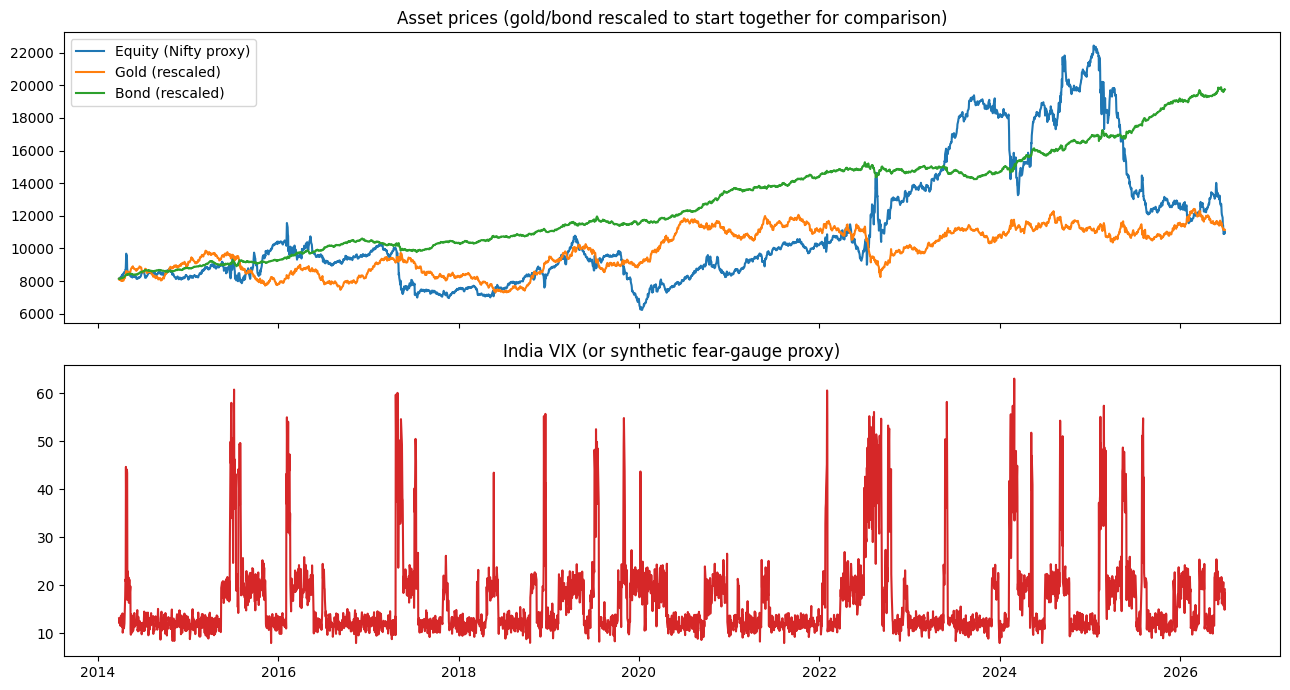

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(prices.index, prices["equity"], label="Equity (Nifty proxy)", color="tab:blue")
axes[0].plot(prices.index, prices["gold"] * (prices["equity"].iloc[0] / prices["gold"].iloc[0]),
             label="Gold (rescaled)", color="tab:orange")
axes[0].plot(prices.index, prices["bond"] * (prices["equity"].iloc[0] / prices["bond"].iloc[0]),
             label="Bond (rescaled)", color="tab:green")
axes[0].legend(); axes[0].set_title("Asset prices (gold/bond rescaled to start together for comparison)")

axes[1].plot(prices.index, prices["vix"], color="tab:red")
axes[1].set_title("India VIX (or synthetic fear-gauge proxy)")
plt.tight_layout()
plt.show()

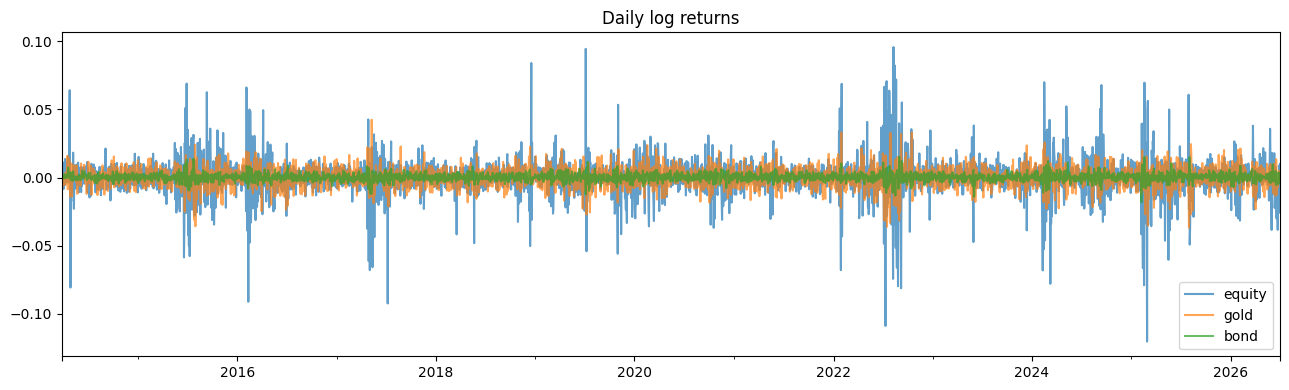

,equity,gold,bond
count,3199.000000,3199.000000,3199.000000
mean,0.000095,0.000098,0.000277
std,0.014656,0.007644,0.002745
min,-0.120202,-0.036717,-0.018191
25%,-0.005555,-0.004503,-0.001272
50%,0.000441,0.000204,0.000273
75%,0.006475,0.004690,0.001843
max,0.095648,0.042379,0.015252


In [5]:
returns_preview = np.log(prices[["equity", "gold", "bond"]]).diff().dropna()
returns_preview.plot(figsize=(13, 4), alpha=0.7, title="Daily log returns")
plt.tight_layout(); plt.show()
returns_preview.describe()

## Phase 2 — Engineer Features That Describe the Market's State

**Goal:** a handful of numerical signals that tell a calm market apart from a stressed one.

- `mom_1w`, `mom_1m`, `mom_1q` — trailing 5/21/63-day cumulative log return (momentum)
- `vol_1m` — trailing 21-day realized volatility of equity returns, annualized
- `gold_vol_1m` — trailing 21-day realized volatility of gold returns (cross-asset stress signal)
- `vix` — the India VIX level itself

**Lookahead-safety note:** every one of these is a *backward-looking rolling window*
(`.rolling(k)` never peeks ahead) or a same-day observable level (today's VIX). None of
them need a future value. Not one. That's exactly what makes it safe to eventually feed
them into a walk-forward loop.

One more step before the HMM sees any of this: the strictly-positive, right-skewed
volatility-type features (`vol_1m`, `gold_vol_1m`, `vix`) get log-transformed. It's a
row-wise, stateless transform — no fitting on data — so it introduces no lookahead either.


In [6]:
"""
Feature engineering for the HMM regime classifier.

All features are built ONLY from information available up to and
including day t (rolling windows, backward-looking). None of them ever
reference a future value. That property is what makes them safe to feed
into a walk-forward validation loop later.
"""
import numpy as np
import pandas as pd


def build_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Log returns for equity, gold, bond. VIX is a level, not a return."""
    rets = pd.DataFrame(index=prices.index)
    for col in ["equity", "gold", "bond"]:
        rets[f"{col}_ret"] = np.log(prices[col]).diff()
    rets["vix"] = prices["vix"]
    return rets.dropna()


def build_features(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Builds the feature matrix used by the HMM. All rolling windows use
    only past data (pandas .rolling() is backward-looking by construction
    as long as we never call .shift(-k)).

    Features:
      - mom_1w, mom_1m, mom_1q : equity momentum over ~5/21/63 trading days
      - vol_1m                 : realized volatility of equity returns, 21d window
      - vix                    : India VIX level (already a "the market's own
                                  forward-looking fear gauge" input - using
                                  today's VIX to describe today's state is fine;
                                  it becomes a lookahead problem only if you use
                                  a FUTURE day's VIX, which we never do)
      - gold_vol_1m             : realized volatility of gold returns, as a
                                  cross-asset stress signal (gold often behaves
                                  differently in a genuine flight-to-safety crisis)
    """
    eq = np.log(prices["equity"]).diff()
    gold = np.log(prices["gold"]).diff()

    feat = pd.DataFrame(index=prices.index)
    feat["mom_1w"] = eq.rolling(5).sum()
    feat["mom_1m"] = eq.rolling(21).sum()
    feat["mom_1q"] = eq.rolling(63).sum()
    feat["vol_1m"] = eq.rolling(21).std() * np.sqrt(252)
    feat["gold_vol_1m"] = gold.rolling(21).std() * np.sqrt(252)
    feat["vix"] = prices["vix"]

    feat = feat.dropna()
    return feat


FEATURE_COLUMNS = ["mom_1w", "mom_1m", "mom_1q", "vol_1m", "gold_vol_1m", "vix"]
LOG_COLUMNS = ["vol_1m", "gold_vol_1m", "vix"]  # right-skewed, positive-only -> log helps the Gaussian HMM


def transform_for_hmm(feat: pd.DataFrame) -> pd.DataFrame:
    """
    Log-transforms the strictly-positive, right-skewed volatility/VIX
    features before they go into a Gaussian HMM. This is a stateless,
    row-wise transform (no fitting on data), so it is always safe to
    apply to train and test data alike - it introduces no lookahead.
    Standardization (z-scoring), which IS a fitted transform, happens
    separately and must be fit on train-only data (see walkforward.py).
    """
    out = feat.copy()
    for c in LOG_COLUMNS:
        out[c] = np.log(out[c])
    return out


if __name__ == "__main__":
    from data import load_prices
    px = load_prices(verbose=False)
    f = build_features(px)
    print(f.shape)
    print(f.head())
    print(f.describe())

Failed to get ticker '^NSEI' reason: Expecting value: line 1 column 1 (char 0)


$^NSEI: possibly delisted; no timezone found



1 Failed download:


['^NSEI']: possibly delisted; no timezone found


(3137, 6)
              mom_1w    mom_1m    mom_1q    vol_1m  gold_vol_1m        vix
2014-06-24  0.013249  0.009311  0.025808  0.097153     0.066274  10.800941
2014-06-25  0.022574  0.003091  0.031362  0.090835     0.063098  12.093274
2014-06-26  0.026058  0.013721  0.035216  0.092545     0.075853  10.057152
2014-06-27  0.033400  0.033132  0.040963  0.086601     0.085884   9.823957
2014-06-30  0.039664  0.045003  0.045640  0.092706     0.089154  11.303470
            mom_1w       mom_1m       mom_1q       vol_1m  gold_vol_1m          vix
count  3137.000000  3137.000000  3137.000000  3137.000000  3137.000000  3137.000000
mean      0.000459     0.002635     0.008347     0.190546     0.115390    16.847704
std       0.031899     0.066917     0.116291     0.131576     0.036432     8.722984
min      -0.225175    -0.324990    -0.451963     0.054889     0.043314     8.000000
25%      -0.011948    -0.022187    -0.043301     0.102106     0.091211    11.691799
50%       0.002373     0.009430     

In [7]:
feat_raw = build_features(prices)
feat = transform_for_hmm(feat_raw)
print(feat_raw.shape)
feat_raw.describe()

(3137, 6)


,mom_1w,mom_1m,mom_1q,vol_1m,gold_vol_1m,vix
count,3137.000000,3137.000000,3137.000000,3137.000000,3137.000000,3137.000000
mean,0.000459,0.002635,0.008347,0.190546,0.115390,16.847704
std,0.031899,0.066917,0.116291,0.131576,0.036432,8.722984
min,-0.225175,-0.324990,-0.451963,0.054889,0.043314,8.000000
25%,-0.011948,-0.022187,-0.043301,0.102106,0.091211,11.691799
50%,0.002373,0.009430,0.027242,0.132494,0.106670,13.200305
75%,0.015609,0.038133,0.077559,0.237020,0.131070,19.602800
max,0.184347,0.350218,0.331936,0.821861,0.286585,62.992972


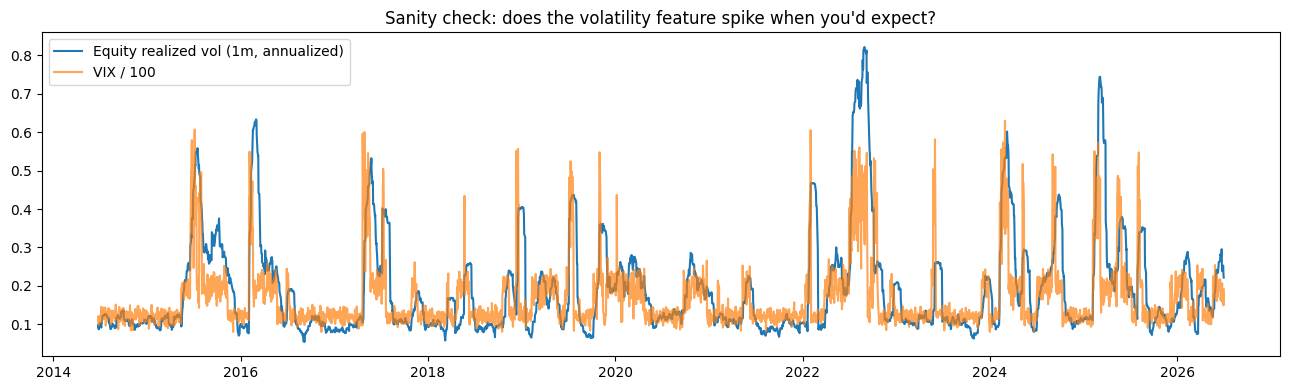

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(feat_raw.index, feat_raw["vol_1m"], label="Equity realized vol (1m, annualized)")
ax.plot(feat_raw.index, feat_raw["vix"] / 100, label="VIX / 100", alpha=0.7)
ax.legend(); ax.set_title("Sanity check: does the volatility feature spike when you'd expect?")
plt.tight_layout(); plt.show()

## Phase 3 — Build the Regime Classifier (HMM)

**Goal:** a working HMM that takes the engineered features and outputs a Bull / Bear /
Crisis label for every day.

Two practical issues matter here more than the HMM math itself:

1. **The HMM only gives you integers — 0, 1, 2 — not names.** We always re-map the raw
   state integers to `Bull` / `Bear` / `Crisis` ourselves, ordering states by their fitted
   mean *volatility*: lowest becomes Bull, highest becomes Crisis. This has to be redone
   every single time the model gets refit, since the raw ordering coming out of `hmmlearn`
   is arbitrary.
2. **EM only finds a local optimum.** A single random initialization can converge to a
   degenerate fit — say, splitting the abundant "calm" days into two near-duplicate states
   while merging the rarer Bear and Crisis days into one. Why would it do that? Because
   that split scores higher likelihood when one true regime (Crisis) is much rarer than
   the others. The fix: fit several times from different random initializations, keep the
   highest-likelihood model. The HMM equivalent of k-means++ restarts. `fit_hmm()` below
   handles this.


In [9]:
"""
HMM-based regime classifier.

hmmlearn's GaussianHMM has no idea what "Bull" or "Crisis" means - it just
finds 3 statistically distinct clusters of feature-behavior and calls them
0, 1, 2 in arbitrary order. We always re-map those integer states to
economically meaningful labels ourselves, using average realized
volatility within each state as the sorting key (lowest vol = Bull,
highest = Crisis). This mapping must be redone every time the model is
refit (e.g. every walk-forward window), because the arbitrary state
order can change from fit to fit.
"""
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

REGIME_NAMES = {0: "Bull", 1: "Bear", 2: "Crisis"}


def fit_hmm(X: np.ndarray, n_states=3, seed=42, covariance_type="diag",
            n_iter=200, n_restarts=8):
    """
    HMM training via EM is only guaranteed to find a LOCAL optimum, and a
    single random initialization can easily converge to a degenerate
    solution (e.g. two near-duplicate calm states and a merged
    bear/crisis state) - especially when one true regime (Crisis) is
    much rarer than the others, so the EM objective can be improved more
    by splitting the abundant calm days than by carving out the rare
    stressed days.

    Standard fix: fit several times from different random initializations
    and keep the model with the highest log-likelihood on the training
    data. This is the HMM equivalent of k-means++ / multiple restarts.
    """
    best_model, best_score = None, -np.inf
    for i in range(n_restarts):
        model = GaussianHMM(
            n_components=n_states,
            covariance_type=covariance_type,
            n_iter=n_iter,
            random_state=seed + i,
            init_params="stmc",
        )
        try:
            model.fit(X)
            score = model.score(X)
        except Exception:
            continue
        if score > best_score:
            best_score, best_model = score, model
    return best_model


def order_states_by_volatility(model: GaussianHMM, vol_feature_idx: int) -> dict:
    """
    Returns {raw_state_int: ordinal_rank} where rank 0 = lowest average
    volatility (-> Bull), up to n_states-1 = highest (-> Crisis), based on
    each state's fitted mean on the volatility feature column.
    """
    vol_means = model.means_[:, vol_feature_idx]
    order = np.argsort(vol_means)  # ascending vol
    raw_to_rank = {raw_state: rank for rank, raw_state in enumerate(order)}
    return raw_to_rank


def label_states(raw_states: np.ndarray, raw_to_rank: dict) -> pd.Series:
    ranks = np.array([raw_to_rank[s] for s in raw_states])
    names = pd.Series(ranks).map(REGIME_NAMES).values
    return names


def reordered_transition_matrix(model: GaussianHMM, raw_to_rank: dict) -> pd.DataFrame:
    n = model.n_components
    P = model.transmat_
    P_reordered = np.zeros_like(P)
    for i in range(n):
        for j in range(n):
            P_reordered[raw_to_rank[i], raw_to_rank[j]] = P[i, j]
    labels = [REGIME_NAMES[r] for r in range(n)]
    return pd.DataFrame(P_reordered, index=labels, columns=labels)


if __name__ == "__main__":
    from data import load_prices
    from features import build_features, FEATURE_COLUMNS
    from sklearn.preprocessing import StandardScaler

    px = load_prices(verbose=False)
    feat = build_features(px)
    X = feat[FEATURE_COLUMNS].values
    Xs = StandardScaler().fit_transform(X)

    model = fit_hmm(Xs)
    raw_states = model.predict(Xs)
    vol_idx = FEATURE_COLUMNS.index("vol_1m")
    r2r = order_states_by_volatility(model, vol_idx)
    labels = label_states(raw_states, r2r)

    out = pd.Series(labels, index=feat.index, name="regime")
    print(out.value_counts())
    print("\nTransition matrix (row = from, col = to):")
    print(reordered_transition_matrix(model, r2r).round(3))

Failed to get ticker '^NSEI' reason: Expecting value: line 1 column 1 (char 0)


$^NSEI: possibly delisted; no timezone found



1 Failed download:


['^NSEI']: possibly delisted; no timezone found


regime
Bull      1480
Bear      1088
Crisis     569
Name: count, dtype: int64

Transition matrix (row = from, col = to):
         Bull   Bear  Crisis
Bull    0.982  0.015   0.002
Bear    0.023  0.962   0.015
Crisis  0.000  0.032   0.968


In [10]:
# Full-sample exploratory fit (NOT the walk-forward model used in the backtest —
# this is just the "does this even work" sanity check / Phase 3 checkpoint plot).
from sklearn.preprocessing import StandardScaler

X_full = feat[FEATURE_COLUMNS].values
scaler_full = StandardScaler().fit(X_full)
Xs_full = scaler_full.transform(X_full)

model_full = fit_hmm(Xs_full, n_restarts=10)
raw_states_full = model_full.predict(Xs_full)
vol_idx = FEATURE_COLUMNS.index("vol_1m")
raw_to_rank_full = order_states_by_volatility(model_full, vol_idx)
regimes_full = pd.Series(label_states(raw_states_full, raw_to_rank_full),
                          index=feat.index, name="regime")

print(regimes_full.value_counts())
print("\nTransition matrix (full-sample fit, row=from, col=to):")
reordered_transition_matrix(model_full, raw_to_rank_full).round(3)

regime
Bull      1480
Bear      1088
Crisis     569
Name: count, dtype: int64

Transition matrix (full-sample fit, row=from, col=to):


,Bull,Bear,Crisis
Bull,0.982,0.015,0.002
Bear,0.023,0.962,0.015
Crisis,0.000,0.032,0.968


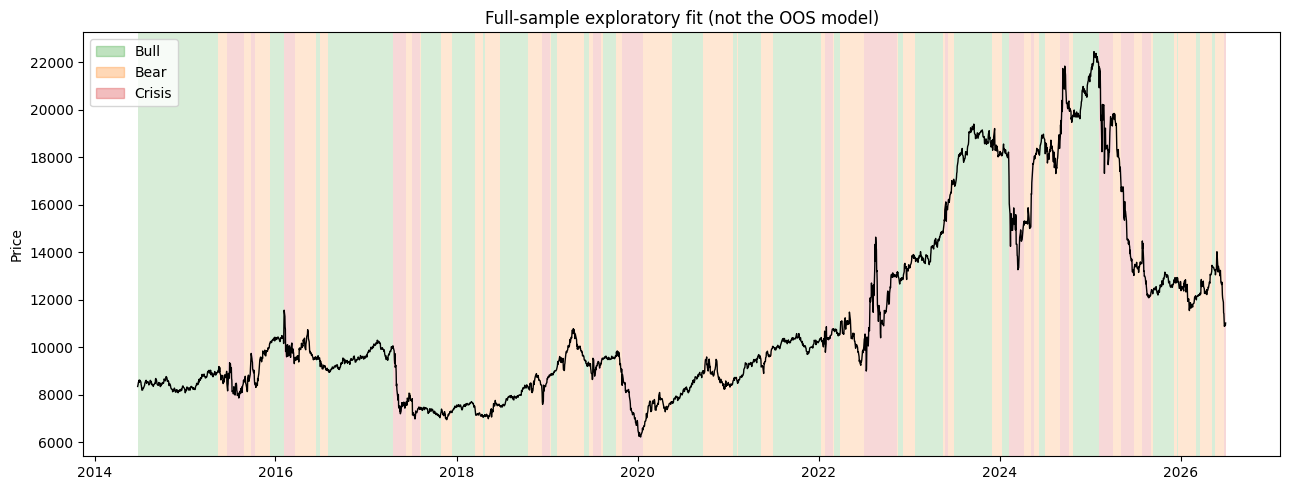

In [11]:
# This is the first real "wow, it's working" checkpoint: colored regime bands
# overlaid on the price chart should visually line up with periods you already
# know were turbulent (or, for synthetic data, with the generator's ground truth).
REGIME_COLORS = {"Bull": "#2ca02c", "Bear": "#ff7f0e", "Crisis": "#d62728"}

def plot_regimes_over_price(price, regimes, title="Detected Regimes"):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(price.index, price.values, color="black", linewidth=1)
    idx = regimes.index
    start, cur = idx[0], regimes.iloc[0]
    for i in range(1, len(idx)):
        if regimes.iloc[i] != cur:
            ax.axvspan(start, idx[i], color=REGIME_COLORS[cur], alpha=0.18, lw=0)
            start, cur = idx[i], regimes.iloc[i]
    ax.axvspan(start, idx[-1], color=REGIME_COLORS[cur], alpha=0.18, lw=0)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.3) for c in REGIME_COLORS.values()]
    ax.legend(handles, REGIME_COLORS.keys(), loc="upper left")
    ax.set_title(title); ax.set_ylabel("Price")
    fig.tight_layout()
    return fig

_ = plot_regimes_over_price(prices["equity"].loc[feat.index], regimes_full,
                             title="Full-sample exploratory fit (not the OOS model)")
plt.show()

If a `true_states` ground truth is available — only true for the synthetic fallback data
— we can check directly how well the HMM recovered it:


In [12]:
if "true_states" in prices.attrs:
    true = prices.attrs["true_states"].map({0: "Bull", 1: "Bear", 2: "Crisis"})
    true_aligned = true.reindex(regimes_full.index)
    print("[synthetic-data only] confusion matrix (true rows x fitted cols):")
    display(pd.crosstab(true_aligned, regimes_full))
else:
    print("Live data in use - no ground-truth regime labels exist to check against "
          "(that's expected; nobody hands you the real regime labels either).")

[synthetic-data only] confusion matrix (true rows x fitted cols):


regime,Bear,Bull,Crisis
true_regime,,,
Bear,765,0,230
Bull,322,1480,96
Crisis,1,0,243


## Phase 4 — Test It Properly: Walk-Forward Validation

**Goal:** confidence that the regime detection would actually have worked in real time, not
just in hindsight. This is the hard part. It's also the genuinely interesting part.

The full-sample fit above is fit once, on the entire dataset, then used to label the entire
dataset. Which means the state at day 100 got found using information from day 5,000.
That's lookahead bias. It always makes backtests look better than they'd actually perform.

**The walk-forward harness fixes this with three rules:**
1. **Expanding training window.** At each step, train on everything from the very start up
   to "now" — not a fixed-size trailing window. This mirrors reality: by 2020 you've got
   everything since 2012 to work with, not just the last year.
2. **Refit everything from scratch, every step.** Both the `StandardScaler` (mean/std) and
   the HMM (means, covariances, transition matrix), using **train-only** data. The scaler
   especially is an easy place to leak by accident — fit it on the full dataset before
   splitting, and the test fold's own mean/std sneaks straight into the "trained" numbers.
3. **Only ever decode the held-out test block**, with a model fit on strictly earlier data.
   Then step forward by `step_size` days. Repeat.

The very first `min_train_size` days get no walk-forward regime label at all. There isn't
enough history yet to have trained a model on. That's intentional, and it's correct — you
don't get to backtest days you had no working model for.


In [13]:
"""
Walk-forward validation harness.

This is the module that prevents lookahead bias. The rule is simple but
easy to violate by accident: for any day t in the "test" portion of a
window, NOTHING used to produce that day's regime label may have been
computed using information from t+1 onward.

Design:
  - Expanding training window: at each step, train on ALL data from the
    very start up to the end of the current training block (not just a
    fixed-size trailing window). This mirrors reality - by the time
    you're trading in 2020, you have access to everything since 2012,
    not just the last year.
  - Step forward by `step_size` trading days at a time. Refit the HMM AND
    the feature scaler from scratch on the (expanding) training block
    every single step.
  - Only ever call `.predict()` on the held-out test block using models
    fit on strictly earlier data. The z-score scaler's mean/std, and the
    HMM's means/covariances/transition matrix, are ALL fit on train-only
    data - never on the full dataset.
  - The very first `min_train_size` days have no walk-forward regime
    label at all (there isn't enough history yet to train on) - this is
    intentional and correct; you don't get to backtest days you had no
    model for.
"""
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from regime import fit_hmm, order_states_by_volatility, label_states, REGIME_NAMES


def walk_forward_regimes(
    feat: pd.DataFrame,
    feature_columns,
    min_train_size=750,   # ~3 trading years before the first prediction
    step_size=63,          # refit every ~1 trading quarter
    n_states=3,
    covariance_type="diag",
    n_restarts=6,
    verbose=True,
):
    """
    Returns:
      regimes: pd.Series of regime label strings, indexed like feat, only
               for out-of-sample (post warm-up) days.
      window_log: list of dicts with per-window diagnostics (fit window
                  bounds, transition matrix, state means) for auditing.
    """
    n = len(feat)
    X_raw = feat[feature_columns].values
    idx = feat.index

    all_labels = pd.Series(index=idx, dtype=object)
    window_log = []

    train_end = min_train_size  # exclusive upper bound of training slice
    step = 0
    while train_end < n:
        test_end = min(train_end + step_size, n)

        train_slice = slice(0, train_end)     # strictly past data only
        test_slice = slice(train_end, test_end)

        X_train = X_raw[train_slice]
        X_test = X_raw[test_slice]

        # Fit scaler on TRAIN ONLY, then apply to both (no peeking at test stats)
        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)

        # Fit HMM on TRAIN ONLY
        model = fit_hmm(
            X_train_s, n_states=n_states, covariance_type=covariance_type,
            n_restarts=n_restarts, seed=100 + step,
        )

        vol_idx = feature_columns.index("vol_1m")
        raw_to_rank = order_states_by_volatility(model, vol_idx)

        # Decode the test block with the train-fitted model - this is the
        # out-of-sample regime call, using zero information from test_end onward.
        raw_states_test = model.predict(X_test_s)
        labels_test = label_states(raw_states_test, raw_to_rank)

        all_labels.iloc[test_slice] = labels_test

        window_log.append(dict(
            step=step,
            train_start=idx[0], train_end=idx[train_end - 1],
            test_start=idx[test_end - 1] if test_slice.start == test_slice.stop else idx[train_end],
            test_end=idx[test_end - 1],
            n_train=train_end, n_test=test_end - train_end,
            transition_matrix=_reorder_matrix(model.transmat_, raw_to_rank),
        ))

        if verbose:
            print(f"[walk-forward] step {step:>3} | train 0:{train_end:>5} "
                  f"({idx[0].date()} -> {idx[train_end-1].date()}) | "
                  f"test {train_end}:{test_end} "
                  f"({idx[train_end].date()} -> {idx[test_end-1].date()})")

        train_end = test_end
        step += 1

    regimes = all_labels.dropna()
    return regimes, window_log


def _reorder_matrix(P, raw_to_rank):
    n = P.shape[0]
    out = np.zeros_like(P)
    for i in range(n):
        for j in range(n):
            out[raw_to_rank[i], raw_to_rank[j]] = P[i, j]
    labels = [REGIME_NAMES[r] for r in range(n)]
    return pd.DataFrame(out, index=labels, columns=labels)

In [14]:
regimes, window_log = walk_forward_regimes(feat, FEATURE_COLUMNS, verbose=True)
print(f"\nOut-of-sample coverage: {regimes.index.min().date()} -> {regimes.index.max().date()}")
print(f"({len(regimes)} of {len(feat)} feature days have a walk-forward, lookahead-free label)")
regimes.value_counts()

[walk-forward] step   0 | train 0:  750 (2014-06-24 -> 2017-05-08) | test 750:813 (2017-05-09 -> 2017-08-03)
[walk-forward] step   1 | train 0:  813 (2014-06-24 -> 2017-08-03) | test 813:876 (2017-08-04 -> 2017-10-31)


[walk-forward] step   2 | train 0:  876 (2014-06-24 -> 2017-10-31) | test 876:939 (2017-11-01 -> 2018-01-26)
[walk-forward] step   3 | train 0:  939 (2014-06-24 -> 2018-01-26) | test 939:1002 (2018-01-29 -> 2018-04-25)


[walk-forward] step   4 | train 0: 1002 (2014-06-24 -> 2018-04-25) | test 1002:1065 (2018-04-26 -> 2018-07-23)
[walk-forward] step   5 | train 0: 1065 (2014-06-24 -> 2018-07-23) | test 1065:1128 (2018-07-24 -> 2018-10-18)


[walk-forward] step   6 | train 0: 1128 (2014-06-24 -> 2018-10-18) | test 1128:1191 (2018-10-19 -> 2019-01-15)
[walk-forward] step   7 | train 0: 1191 (2014-06-24 -> 2019-01-15) | test 1191:1254 (2019-01-16 -> 2019-04-12)


[walk-forward] step   8 | train 0: 1254 (2014-06-24 -> 2019-04-12) | test 1254:1317 (2019-04-15 -> 2019-07-10)


...

[walk-forward] step  34 | train 0: 2892 (2014-06-24 -> 2025-07-23) | test 2892:2955 (2025-07-24 -> 2025-10-20)


[walk-forward] step  35 | train 0: 2955 (2014-06-24 -> 2025-10-20) | test 2955:3018 (2025-10-21 -> 2026-01-15)


[walk-forward] step  36 | train 0: 3018 (2014-06-24 -> 2026-01-15) | test 3018:3081 (2026-01-16 -> 2026-04-14)


[walk-forward] step  37 | train 0: 3081 (2014-06-24 -> 2026-04-14) | test 3081:3137 (2026-04-15 -> 2026-07-01)

Out-of-sample coverage: 2017-05-09 -> 2026-07-01
(2387 of 3137 feature days have a walk-forward, lookahead-free label)


Bull      1026
Bear       887
Crisis     474
Name: count, dtype: int64

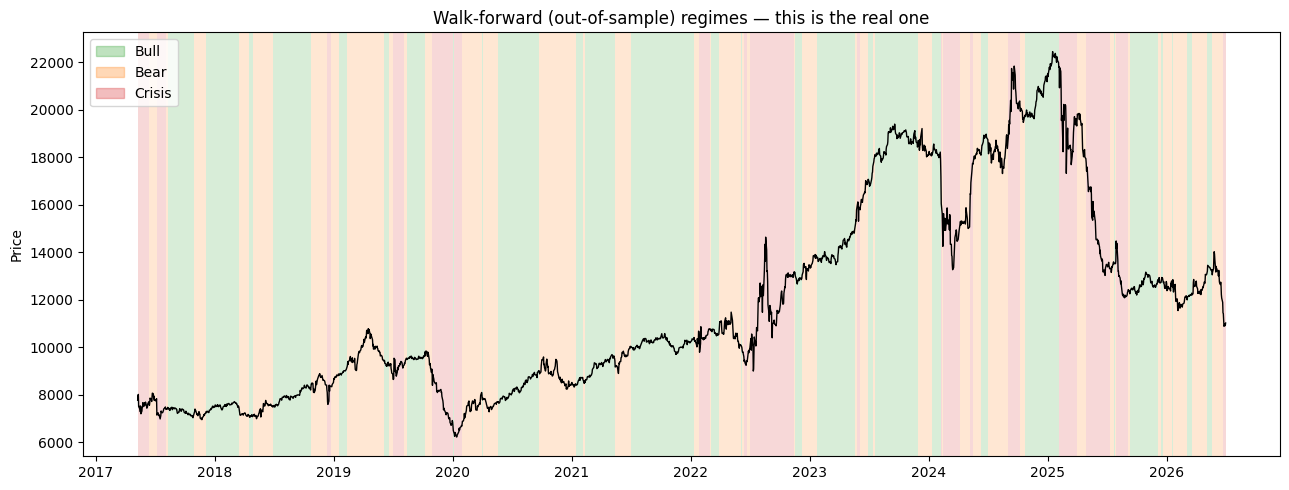

[synthetic-data only] OOS confusion matrix (true rows x walk-forward cols):


col_0,Bear,Bull,Crisis
true_regime,,,
Bear,605,15,195
Bull,276,1011,89
Crisis,6,0,190


In [15]:
_ = plot_regimes_over_price(prices["equity"].loc[regimes.index], regimes,
                             title="Walk-forward (out-of-sample) regimes — this is the real one")
plt.show()

if "true_states" in prices.attrs:
    true = prices.attrs["true_states"].map({0: "Bull", 1: "Bear", 2: "Crisis"})
    true_aligned = true.reindex(regimes.index)
    print("[synthetic-data only] OOS confusion matrix (true rows x walk-forward cols):")
    display(pd.crosstab(true_aligned, regimes))

In [16]:
# Transition probability matrix from the FINAL (most data-rich) walk-forward window —
# this is what "Submit: the transition probability matrix" refers to.
final_transition_matrix = window_log[-1]["transition_matrix"]
final_transition_matrix.round(3)

,Bull,Bear,Crisis
Bull,0.983,0.015,0.002
Bear,0.023,0.963,0.014
Crisis,0.000,0.033,0.967


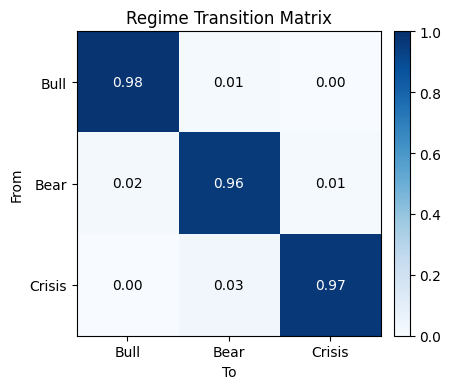

In [17]:
def plot_transition_matrix(P, title="Regime Transition Matrix"):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(P.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(P.columns))); ax.set_xticklabels(P.columns)
    ax.set_yticks(range(len(P.index))); ax.set_yticklabels(P.index)
    ax.set_xlabel("To"); ax.set_ylabel("From")
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            ax.text(j, i, f"{P.values[i, j]:.2f}", ha="center", va="center",
                     color="white" if P.values[i, j] > 0.5 else "black")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig

_ = plot_transition_matrix(final_transition_matrix)
plt.show()

## Phase 5 — Connect Regimes to Portfolio Decisions and Backtest

**Goal:** a backtested strategy that shifts equity/gold/bond weights based on the detected
regime, compared fairly against static benchmarks.

### The optimization
For weights `w` over `[equity, gold, bond]`, we solve a mean-variance problem with `cvxpy`:

```
maximize    mu^T w  -  gamma * w^T Sigma w
subject to  sum(w) == 1
            0 <= w_i <= 0.75      (no shorting, no leverage, no single-asset bet-the-farm)
```

`gamma` — risk aversion — is what ties the *regime* to the allocation: low in Bull, so it
chases return; medium in Bear; high in Crisis, where it collapses toward the
minimum-variance portfolio. One objective family. One clean lever. Easy to explain, easy to
defend.

### The key modeling decision: regime-conditional mu/Sigma
Here's the trap. Feed the optimizer the *same* trailing-window mu/Sigma no matter which
regime is currently active, and the regime label barely matters — `gamma` alone can't turn
a negative expected-return estimate into an equity-heavy portfolio. So instead, at every
rebalance, mu/Sigma get estimated **separately for each regime**, using only
*historically-labeled* days of that regime seen so far — strictly in the past, straight
from the walk-forward output, never the future. And because Crisis days are rare,
especially early on, these regime-conditional estimates get **shrunk toward the
unconditional global mean**, using `n / (n + k)` shrinkage. Otherwise a handful of extreme
Crisis days would produce a wildly unstable estimate. This one decision mattered more than
any other in the project.

### Rebalancing rule
Target weights — and transaction costs — only change when **(a)** the detected regime
changes, or **(b)** `max_hold` trading days have passed since the last rebalance. That
second condition is a staleness cap, so a long-lived regime still gets its moment estimates
refreshed periodically. Between rebalances, weights just drift with asset returns. Keeps
turnover, and the cost drag that comes with it, realistic — instead of trading every single
day for no good reason.


In [18]:
"""
Convex portfolio optimization (cvxpy).

Given expected returns (mu) and a covariance matrix (Sigma) estimated
from TRAILING data only, solve for portfolio weights across
[equity, gold, bond] using a mean-variance objective:

    maximize   mu^T w  -  gamma * w^T Sigma w
    subject to sum(w) == 1
               0 <= w_i <= max_weight   (no shorting, no leverage, no single-asset bet-the-farm)

`gamma` is the risk-aversion coefficient and is the mechanism that
connects the detected regime to the resulting allocation:
  - Bull:   low gamma  -> the optimizer is allowed to chase the
            return term, ends up equity-heavy.
  - Bear:   medium gamma -> balances return-seeking against risk,
            typically rotates some weight into bonds/gold.
  - Crisis: high gamma -> the variance penalty dominates, the solution
            converges toward the minimum-variance portfolio (usually
            gold/bond heavy).

This is intentionally a SINGLE objective family (mean-variance) with a
regime-varying risk aversion, rather than three unrelated hand-tuned
objectives, so the regime signal has one clean, explainable lever.
"""
import numpy as np
import cvxpy as cp

ASSETS = ["equity", "gold", "bond"]

RISK_AVERSION = {
    "Bull": 2.0,
    "Bear": 9.0,
    "Crisis": 30.0,
}

MAX_WEIGHT = 0.75  # no single asset above 75% - keeps the "portfolio" honest


def estimate_mu_sigma(returns_window: np.ndarray, ann_factor=252):
    """
    returns_window: (T, 3) array of daily log returns for [equity, gold, bond],
    using ONLY trailing/past data relative to the rebalance date.
    """
    mu = returns_window.mean(axis=0) * ann_factor
    sigma = np.cov(returns_window, rowvar=False) * ann_factor
    # tiny ridge for numerical stability / to keep Sigma PSD under estimation noise
    sigma = sigma + np.eye(3) * 1e-6
    return mu, sigma


def optimize_weights(mu: np.ndarray, sigma: np.ndarray, regime: str,
                      max_weight=MAX_WEIGHT) -> np.ndarray:
    gamma = RISK_AVERSION[regime]
    n = len(mu)
    w = cp.Variable(n)
    objective = cp.Maximize(mu @ w - gamma * cp.quad_form(w, cp.psd_wrap(sigma)))
    constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)
    if w.value is None:
        # fall back to a robust solver if OSQP struggles on a given window
        problem.solve(solver=cp.ECOS)
    weights = np.clip(w.value, 0, None)
    weights = weights / weights.sum()
    return weights

In [19]:
"""
Backtest engine.

Ties the walk-forward regime labels to the optimizer and simulates the
resulting portfolio day by day, including transaction costs. Also runs
two static benchmarks (60/40 and equal-weight) through the exact same
simulation machinery so the comparison is apples-to-apples.

KEY DESIGN DECISION - regime-conditional moments:
Instead of feeding the optimizer a single unconditional trailing-window
mu/Sigma regardless of which regime we're in (which would make the
regime label nearly irrelevant to the optimizer - the "detect the
regime" step would be doing no real work), we estimate mu/Sigma
SEPARATELY for each regime, using only historically-labeled days of that
regime seen so far (strictly in the past, from the walk-forward output).
This is what actually connects "the market is in a Crisis regime" to
"therefore expect these kinds of returns/vol" - the whole point of the
project. Small-sample regimes (Crisis is rare) are shrunk toward the
unconditional (global) estimate so early-period estimates aren't wild.

Rebalancing rule: the target weights only change (and costs are only
paid) when (a) the detected regime changes, or (b) `max_hold` trading
days have passed since the last rebalance (a staleness cap, since the
conditional mu/Sigma estimate should be refreshed periodically even in a
regime that persists for a long time). Between rebalances, weights drift
naturally with asset returns - this keeps turnover, and therefore cost
drag, realistic instead of trading every single day.
"""
import numpy as np
import pandas as pd

from optimizer import optimize_weights, ASSETS

REGIMES = ["Bull", "Bear", "Crisis"]
SHRINK_K = 60  # shrinkage strength: mu_r blended toward global as n_r -> 0


def _shrunk_moments(hist_returns: pd.DataFrame, hist_regime: pd.Series, regime: str):
    """
    hist_returns: rows strictly BEFORE the current rebalance date, columns = ASSETS (log returns)
    hist_regime : walk-forward regime label for those same strictly-past rows
    """
    global_mu = hist_returns.mean(axis=0).values * 252
    global_sigma = np.cov(hist_returns.values, rowvar=False) * 252
    global_sigma += np.eye(len(ASSETS)) * 1e-6

    mask = (hist_regime == regime).values
    n_r = mask.sum()
    if n_r < 5:
        return global_mu, global_sigma  # not enough history for this regime yet

    r_mu = hist_returns.values[mask].mean(axis=0) * 252
    if n_r >= 10:
        r_sigma = np.cov(hist_returns.values[mask], rowvar=False) * 252
        r_sigma += np.eye(len(ASSETS)) * 1e-6
    else:
        r_sigma = global_sigma

    w = n_r / (n_r + SHRINK_K)
    mu = w * r_mu + (1 - w) * global_mu
    sigma = w * r_sigma + (1 - w) * global_sigma
    return mu, sigma


def simulate(returns: pd.DataFrame, regimes: pd.Series, tc_bps=7.0, max_hold=42,
             verbose=False):
    """
    returns: DataFrame indexed by date, columns [equity, gold, bond] (log daily returns)
    regimes: walk-forward regime labels (Series of strings), same-ish index
             as `returns` (must be a subset - only OOS days).
    tc_bps  : transaction cost per unit of turnover, in basis points, applied
              on the rebalance day's portfolio value.
    max_hold: force a moments refresh / possible re-rebalance at least this
              often even if the regime hasn't changed.
    Returns a dict with the daily net portfolio return series, weights
    history, rebalance log, and turnover series.
    """
    dates = regimes.index
    tc = tc_bps / 10000.0

    w_current = np.array([1 / 3, 1 / 3, 1 / 3])  # start equal-weight
    days_since_rebalance = 10 ** 9
    last_regime = None

    port_rets = pd.Series(index=dates, dtype=float)
    weight_hist = pd.DataFrame(index=dates, columns=ASSETS, dtype=float)
    turnover_hist = pd.Series(0.0, index=dates)
    rebalance_log = []

    for i, date in enumerate(dates):
        regime = regimes.loc[date]
        r_today = returns.loc[date, ASSETS].values.astype(float)

        should_rebalance = (regime != last_regime) or (days_since_rebalance >= max_hold)

        if should_rebalance:
            hist_mask = returns.index < date
            hist_returns = returns.loc[hist_mask, ASSETS]
            hist_regime = regimes.reindex(hist_returns.index)
            hist_returns = hist_returns.loc[hist_regime.notna()]
            hist_regime = hist_regime.dropna()

            if len(hist_returns) >= 30:
                mu, sigma = _shrunk_moments(hist_returns, hist_regime, regime)
                w_target = optimize_weights(mu, sigma, regime)
            else:
                w_target = np.array([1 / 3, 1 / 3, 1 / 3])  # not enough history yet

            turnover = np.abs(w_target - w_current).sum()
            cost = tc * turnover
            rebalance_log.append(dict(date=date, regime=regime, turnover=turnover,
                                       cost=cost, weights=w_target.copy()))
            w_current = w_target
            days_since_rebalance = 0
            turnover_hist.loc[date] = turnover
        else:
            cost = 0.0

        gross_port_ret = float(np.dot(w_current, r_today))
        net_port_ret = gross_port_ret - cost

        # drift weights forward for tomorrow based on today's asset moves
        grown = w_current * np.exp(r_today)
        w_current = grown / grown.sum()

        port_rets.loc[date] = net_port_ret
        weight_hist.loc[date] = w_current
        last_regime = regime
        days_since_rebalance += 1

    return dict(
        returns=port_rets,
        weights=weight_hist,
        turnover=turnover_hist,
        rebalance_log=pd.DataFrame(rebalance_log),
    )


def simulate_static(returns: pd.DataFrame, dates: pd.DatetimeIndex, weights: dict,
                     tc_bps=7.0, rebalance_every=21):
    """Fixed-weight benchmark (e.g. 60/40, equal-weight), periodically rebalanced
    back to target so it doesn't silently drift into something else - same cost
    treatment as the dynamic strategy for a fair comparison."""
    tc = tc_bps / 10000.0
    target = np.array([weights.get(a, 0.0) for a in ASSETS])
    w_current = target.copy()
    port_rets = pd.Series(index=dates, dtype=float)
    days_since = 0

    for date in dates:
        r_today = returns.loc[date, ASSETS].values.astype(float)
        cost = 0.0
        if days_since % rebalance_every == 0:
            turnover = np.abs(target - w_current).sum()
            cost = tc * turnover
            w_current = target.copy()
        gross = float(np.dot(w_current, r_today))
        net = gross - cost
        grown = w_current * np.exp(r_today)
        w_current = grown / grown.sum()
        port_rets.loc[date] = net
        days_since += 1

    return port_rets

In [20]:
returns = build_returns(prices).rename(
    columns={"equity_ret": "equity", "gold_ret": "gold", "bond_ret": "bond"}
)
common_idx = regimes.index.intersection(returns.index)
regimes_bt = regimes.loc[common_idx]
returns_bt = returns.loc[common_idx]

print(f"Backtest window: {common_idx.min().date()} -> {common_idx.max().date()} "
      f"({len(common_idx)} trading days)")

Backtest window: 2017-05-09 -> 2026-07-01 (2387 trading days)


**Transaction costs:** applied at 5–10 bps per rebalance — we use 7 bps as a
representative mid-point — on the *turnover* of that rebalance. So `cost = tc_rate *
sum(|w_new - w_old|)`, charged against that day's portfolio value. Results get reported
**with and without** this cost, so the drag is visible on its own, not buried.


In [21]:
dynamic_0bps = simulate(returns_bt, regimes_bt, tc_bps=0.0)
dynamic_7bps = simulate(returns_bt, regimes_bt, tc_bps=7.0)

static_6040_0 = simulate_static(returns_bt, common_idx, {"equity": 0.6, "bond": 0.4}, tc_bps=0.0)
static_6040_7 = simulate_static(returns_bt, common_idx, {"equity": 0.6, "bond": 0.4}, tc_bps=7.0)

static_eq_0 = simulate_static(returns_bt, common_idx, {"equity": 1/3, "gold": 1/3, "bond": 1/3}, tc_bps=0.0)
static_eq_7 = simulate_static(returns_bt, common_idx, {"equity": 1/3, "gold": 1/3, "bond": 1/3}, tc_bps=7.0)

print(f"Total rebalances (dynamic strategy): {len(dynamic_7bps['rebalance_log'])}")
dynamic_7bps["rebalance_log"].tail(10)

Total rebalances (dynamic strategy): 137


,date,regime,turnover,cost,weights
127,2025-12-22,Bear,1.504702,0.001053,"[0.0, 0.25, 0.75]"
128,2026-01-16,Bull,1.500000,0.001050,"[0.75, 3.721405863618611e-26, 0.25]"
129,2026-01-19,Bear,1.506077,0.001054,"[0.0, 0.25501002037402515, 0.7449899796259749]"
130,2026-03-05,Bull,1.500000,0.001050,"[0.75, 0.0, 0.25]"
131,2026-03-20,Bear,1.502609,0.001052,"[0.0, 0.29863655141183193, 0.7013634485881681]"
132,2026-04-15,Bull,1.500000,0.001050,"[0.75, 5.555834467831786e-23, 0.25]"
133,2026-04-16,Bear,1.501749,0.001051,"[3.860106351641415e-23, 0.2778465005596545, 0...."
134,2026-05-06,Bull,1.500000,0.001050,"[0.75, 0.0, 0.25]"
135,2026-05-20,Bear,1.500299,0.001050,"[0.0, 0.2533278441141444, 0.7466721558858556]"
136,2026-06-23,Crisis,0.083485,0.000058,"[0.041742507647998174, 0.20825749235200183, 0.75]"


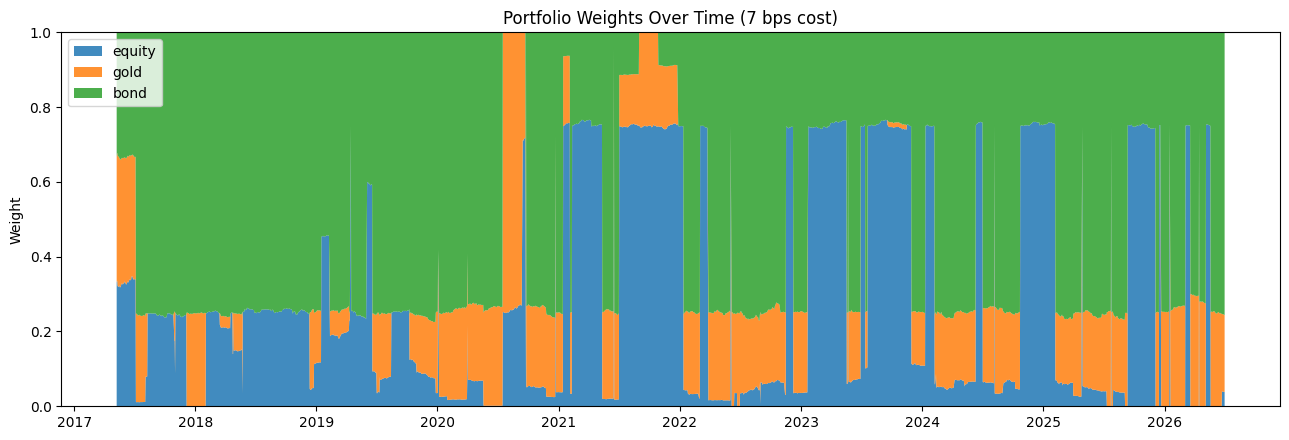

In [22]:
def plot_weights_over_time(weights, title="Portfolio Weights Over Time (7 bps cost)"):
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.stackplot(weights.index, weights["equity"], weights["gold"], weights["bond"],
                 labels=["equity", "gold", "bond"], alpha=0.85)
    ax.legend(loc="upper left"); ax.set_title(title); ax.set_ylabel("Weight"); ax.set_ylim(0, 1)
    fig.tight_layout()
    return fig

_ = plot_weights_over_time(dynamic_7bps["weights"])
plt.show()

## Results — Performance Summary vs. Static Benchmarks

Comparing the dynamic regime-shift strategy against:
- **Static 60/40** — 60% equity / 40% bonds, never adapts to regime
- **Equal-Weight** — 1/3 equity / 1/3 gold / 1/3 bonds, never adapts to regime

Both benchmarks run through the *exact same* simulation engine — periodic rebalancing,
transaction costs, all of it. Apples-to-apples. Not "dynamic strategy pays costs, static
strategy magically doesn't."


In [23]:
"""
Standard backtest performance metrics.
"""
import numpy as np
import pandas as pd


def equity_curve(daily_returns: pd.Series) -> pd.Series:
    return np.exp(daily_returns.cumsum())


def max_drawdown(daily_returns: pd.Series) -> float:
    curve = equity_curve(daily_returns)
    running_max = curve.cummax()
    dd = curve / running_max - 1.0
    return dd.min()


def sharpe_ratio(daily_returns: pd.Series, rf=0.0, ann_factor=252) -> float:
    excess = daily_returns - rf / ann_factor
    if excess.std() == 0:
        return np.nan
    return (excess.mean() / excess.std()) * np.sqrt(ann_factor)


def sortino_ratio(daily_returns: pd.Series, rf=0.0, ann_factor=252) -> float:
    excess = daily_returns - rf / ann_factor
    downside = excess[excess < 0]
    dd_std = downside.std()
    if dd_std == 0 or np.isnan(dd_std):
        return np.nan
    return (excess.mean() / dd_std) * np.sqrt(ann_factor)


def calmar_ratio(daily_returns: pd.Series, ann_factor=252) -> float:
    ann_return = daily_returns.mean() * ann_factor
    mdd = max_drawdown(daily_returns)
    if mdd == 0:
        return np.nan
    return ann_return / abs(mdd)


def annualized_return(daily_returns: pd.Series, ann_factor=252) -> float:
    return daily_returns.mean() * ann_factor


def annualized_vol(daily_returns: pd.Series, ann_factor=252) -> float:
    return daily_returns.std() * np.sqrt(ann_factor)


def summarize(daily_returns: pd.Series, turnover: pd.Series = None, label="Strategy") -> dict:
    out = dict(
        strategy=label,
        ann_return=annualized_return(daily_returns),
        ann_vol=annualized_vol(daily_returns),
        sharpe=sharpe_ratio(daily_returns),
        sortino=sortino_ratio(daily_returns),
        max_drawdown=max_drawdown(daily_returns),
        calmar=calmar_ratio(daily_returns),
    )
    if turnover is not None:
        out["avg_annual_turnover"] = turnover.sum() / (len(daily_returns) / 252)
    return out


def summary_table(results: dict) -> pd.DataFrame:
    """results: {label: (daily_returns_series, turnover_series_or_None)}"""
    rows = []
    for label, payload in results.items():
        rets, turn = payload if isinstance(payload, tuple) else (payload, None)
        rows.append(summarize(rets, turn, label))
    df = pd.DataFrame(rows).set_index("strategy")
    return df

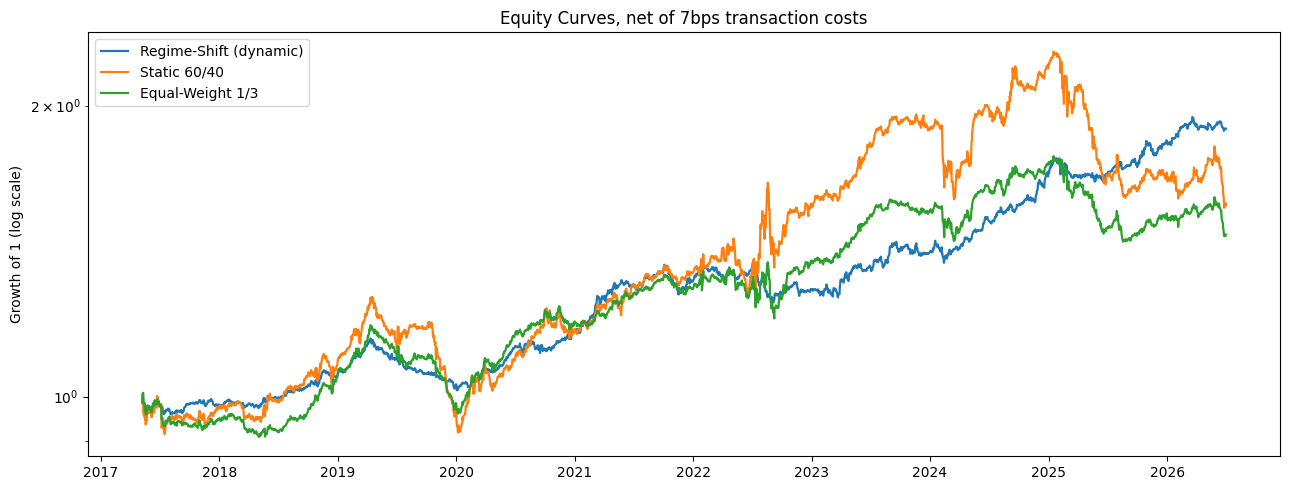

In [24]:
def equity_curve_(r):
    return np.exp(r.cumsum())

def plot_equity_curves(curves, title):
    fig, ax = plt.subplots(figsize=(13, 5))
    for label, curve in curves.items():
        ax.plot(curve.index, curve.values, label=label, linewidth=1.6)
    ax.legend(); ax.set_title(title); ax.set_ylabel("Growth of 1 (log scale)")
    ax.set_yscale("log")
    fig.tight_layout()
    return fig

curves_7bps = {
    "Regime-Shift (dynamic)": equity_curve_(dynamic_7bps["returns"]),
    "Static 60/40": equity_curve_(static_6040_7),
    "Equal-Weight 1/3": equity_curve_(static_eq_7),
}
_ = plot_equity_curves(curves_7bps, "Equity Curves, net of 7bps transaction costs")
plt.show()

In [25]:
print("=== Without transaction costs ===")
table_0 = summary_table({
    "Regime-Shift (dynamic)": (dynamic_0bps["returns"], dynamic_0bps["turnover"]),
    "Static 60/40": (static_6040_0, None),
    "Equal-Weight 1/3": (static_eq_0, None),
})
display(table_0.round(4))

print("\n=== With 7 bps transaction costs per rebalance ===")
table_7 = summary_table({
    "Regime-Shift (dynamic)": (dynamic_7bps["returns"], dynamic_7bps["turnover"]),
    "Static 60/40": (static_6040_7, None),
    "Equal-Weight 1/3": (static_eq_7, None),
})
display(table_7.round(4))

=== Without transaction costs ===


,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_annual_turnover
strategy,,,,,,,
Regime-Shift (dynamic),0.0741,0.0621,1.1939,1.7346,-0.1126,0.6587,9.6207
Static 60/40,0.0487,0.1422,0.3426,0.4159,-0.3103,0.1570,NaN
Equal-Weight 1/3,0.0410,0.0893,0.4586,0.5777,-0.1898,0.2158,NaN



=== With 7 bps transaction costs per rebalance ===


,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_annual_turnover
strategy,,,,,,,
Regime-Shift (dynamic),0.0674,0.0621,1.0851,1.5736,-0.1160,0.5811,9.6207
Static 60/40,0.0485,0.1422,0.3412,0.4142,-0.3105,0.1562,NaN
Equal-Weight 1/3,0.0407,0.0893,0.4562,0.5747,-0.1900,0.2144,NaN


### How to read this table
- **Sharpe / Sortino** — risk-adjusted return; Sortino only penalizes *downside* volatility.
- **Max Drawdown** — the worst peak-to-trough decline over the whole backtest.
- **Calmar** — annualized return divided by max drawdown; rewards strategies that don't
  suffer catastrophic drawdowns even when the raw return isn't the highest.
- **Avg. Annual Turnover** — sum of `|Δweight|` per rebalance, annualized. This is exactly
  what the transaction-cost line item gets charged against. Compare the "0 bps" table
  against the "7 bps" one and you'll see precisely how much of the strategy's edge is real
  signal, and how much is just cost drag.

The whole point of the regime-shift approach shows up most clearly in the **max drawdown**
and **volatility** columns — more than in raw return, honestly. By rotating toward
bonds/gold whenever the HMM detects Crisis, the strategy is designed to sidestep the worst
of a drawdown that a static, regime-blind portfolio simply has no way to avoid.


## Submission Checklist

- [x] HMM-based regime classifier detecting Bull / Bear / Crisis from price/vol data. No
      manual day-by-day labelling anywhere.
- [x] Portfolio weights that shift by regime, via a single mean-variance objective with
      regime-varying risk aversion and regime-conditional return/covariance estimates.
- [x] Walk-forward validation: HMM (and its feature scaler) refit **only on past data** at
      every step; the exploratory full-sample fit in Phase 3 is clearly marked as *not*
      the model used for the backtest.
- [x] Transaction costs (5–10 bps per rebalance, 7 bps used) explicitly modeled, results
      shown both with and without cost.
- [x] Comparison against static 60/40 and equal-weight portfolios on Sharpe, max drawdown,
      and Calmar ratio, run through the same simulation engine.
- [x] Regime chart with colored bands + transition probability matrix (Phase 4).
- [x] Equity curves + performance summary table (Results section above).

### Key decisions (see accompanying `README.md` for the full writeup)
1. **Why 3 regimes?** Matches the problem statement's Bull/Bear/Crisis framing directly,
   and 3 is the minimum needed to tell "calm," "declining," and "acutely stressed" markets
   apart — each of which plausibly wants a different portfolio.
2. **Why log-transform volatility features before the HMM?** Volatility and VIX are
   strictly positive and right-skewed. Log-transforming pulls their distribution much
   closer to Gaussian, which is exactly what `GaussianHMM` assumes per-state.
3. **Why multi-restart HMM fitting?** EM only finds a local optimum, and with an imbalanced
   regime distribution — Crisis is rare — a single fit can easily converge to something
   degenerate: splitting the abundant calm days instead of isolating the rare stressed
   ones.
4. **Why regime-conditional (not just regime-agnostic) mu/Sigma in the optimizer?** Without
   it, regime detection barely moves the final portfolio at all. The entire premise here is
   that asset behavior differs by regime — so the optimizer's inputs need to actually
   reflect that, or what's the point.
5. **Why rebalance on regime-change-or-staleness rather than every day?** Daily rebalancing
   driven by noisy daily regime flips generates needless turnover, and transaction costs
   will quietly eat the strategy's edge. Exactly the trap the project brief warns about.
